## Question 1

In [19]:
import numpy as np

def brownian_sim_interval(time_points):
    delta_t = np.diff(time_points)
    delta_B = np.random.normal(0, np.sqrt(delta_t))
    
    B = np.concatenate(([0], np.cumsum(delta_B)))
    
    return B

t_partition = np.array([0.0, 0.5, 1.5, 2.0])
test = np.zeros((10_000, 4))
for i in range(10_000):
    test[i] = brownian_sim_interval(t_partition)

cov_matrix = np.cov(test, rowvar=False)

mean_b2 = np.mean(test[:, 3])
var_b2 = np.var(test[:, 3])

print("Empirical Covariance Matrix:\n", cov_matrix)
print("\nEmpirical Distribution of B_2:")
print(f"Mean: {mean_b2:.4f}")
print(f"Variance: {var_b2:.4f}")

Empirical Covariance Matrix:
 [[0.         0.         0.         0.        ]
 [0.         0.50274073 0.49217839 0.49579261]
 [0.         0.49217839 1.47750402 1.48557382]
 [0.         0.49579261 1.48557382 1.99347142]]

Empirical Distribution of B_2:
Mean: -0.0037
Variance: 1.9933


## Question 2

<>:23: SyntaxWarning: invalid escape sequence '\p'
<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\p'
<>:27: SyntaxWarning: invalid escape sequence '\m'
/var/folders/s0/2b2p_vwn3gj_82fk6cgm4nfr0000gn/T/ipykernel_42726/2735221915.py:23: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(x_vals, y_vals, 'r-', lw=2, label='Theoretical $2\phi(x)$')
/var/folders/s0/2b2p_vwn3gj_82fk6cgm4nfr0000gn/T/ipykernel_42726/2735221915.py:27: SyntaxWarning: invalid escape sequence '\m'
  plt.title('Distribution of $S_1 = \max\{B_t : 0 \leq t \leq 1\}$')


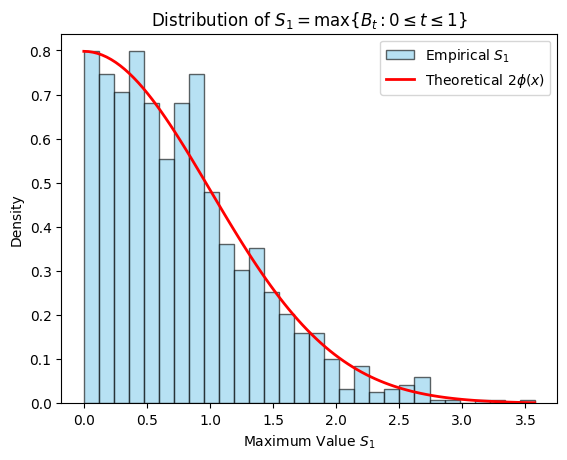

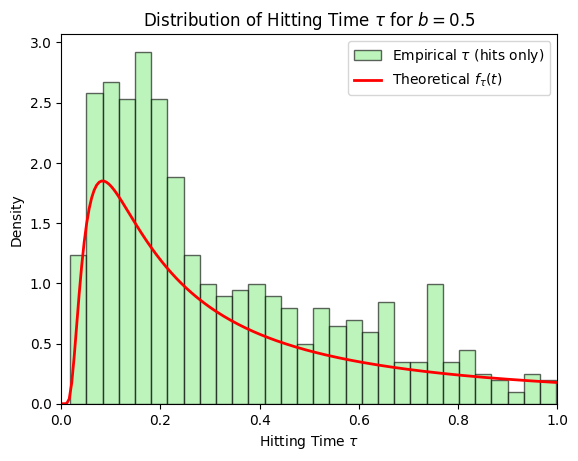

In [33]:
import matplotlib.pyplot as plt
from scipy.stats import norm

# a)
N = 1_000
delta_t = 0.001
time_points = np.arange(0, 1 + delta_t, delta_t)

paths = np.zeros((N, len(time_points)))

for i in range(N):
    delta_B = np.random.normal(0, np.sqrt(delta_t), len(time_points) - 1)
    paths[i] = np.concatenate(([0], np.cumsum(delta_B)))

# b)
S_1 = np.max(paths, axis=1)

plt.hist(S_1, bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Empirical $S_1$')
x_vals = np.linspace(0, np.max(S_1), 100)

y_vals = 2 * norm.pdf(x_vals)

plt.plot(x_vals, y_vals, 'r-', lw=2, label='Theoretical $2\phi(x)$')

plt.xlabel('Maximum Value $S_1$')
plt.ylabel('Density')
plt.title('Distribution of $S_1 = \max\{B_t : 0 \leq t \leq 1\}$')
plt.legend()
plt.show()

# c)
tau_idx = (paths >= 0.5).argmax(axis=1)
tau_vals = time_points[tau_idx]
x_hit = np.any(paths > 0.5, axis=1)
tau = np.where(x_hit, tau_vals, 1.0)

hits = tau[tau < 1.0]
b = 0.5

plt.hist(hits, bins=30, density=True, alpha=0.6, color='lightgreen', edgecolor='black', label='Empirical $\\tau$ (hits only)')

t_vals = np.linspace(0.001, 1, 200)

# calculate theoretical PDF: f_tau(t) = b * t^(-3/2) * phi(b / sqrt(t)) by theorem 4.3.3 in book
theoretical_pdf = b * t_vals**(-1.5) * norm.pdf(b / np.sqrt(t_vals))

plt.plot(t_vals, theoretical_pdf, 'r-', lw=2, label='Theoretical $f_\\tau(t)$')

plt.xlabel('Hitting Time $\\tau$')
plt.ylabel('Density')
plt.title('Distribution of Hitting Time $\\tau$ for $b = 0.5$')
plt.xlim(0, 1)
plt.legend()
plt.show()

## Question 3

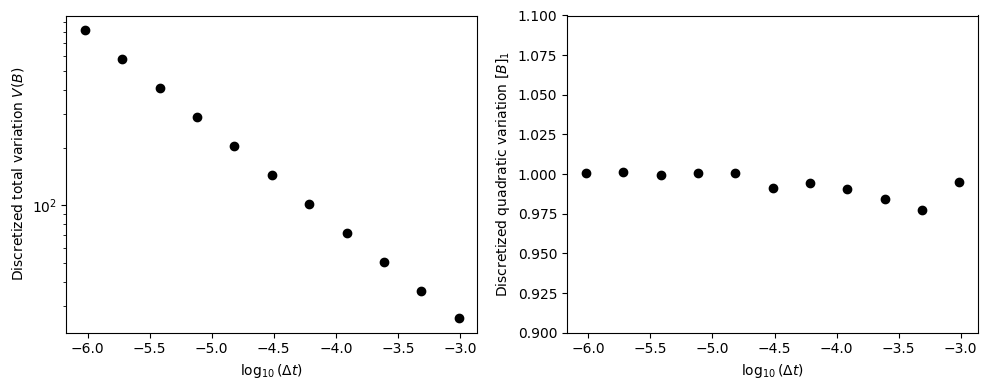

In [40]:
# a)
delta_t = 2**(-20)
time_points = np.arange(0, 1 + delta_t, delta_t)

path = np.zeros(len(time_points))

delta_B = np.random.normal(0, np.sqrt(delta_t), len(time_points) - 1)
path = np.concatenate(([0], np.cumsum(delta_B)))

# b)
V_delta = np.sum(np.abs(delta_B))
quad_var = np.sum(np.abs(delta_B)**2)

# c)
V_deltas = np.zeros(11)
quad_vars = np.zeros(11)

V_deltas[0] = V_delta
quad_vars[0] = quad_var

for i in range(1, 11):
    path = path[::2]
    V_deltas[i] = np.sum(np.abs(np.diff(path)))
    quad_vars[i] = np.sum(np.abs(np.diff(path))**2)
    
dt_vals = 2.0 ** np.arange(-20, -9)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Left panel: Total Variation
ax1.plot(np.log10(dt_vals), V_deltas, 'ko')
ax1.set_yscale('log')  # Logarithmic y-axis for total variation
ax1.set_xlabel('$\\log_{10}(\\Delta t)$')
ax1.set_ylabel('Discretized total variation $V(B)$')

# Right panel: Quadratic Variation
ax2.plot(np.log10(dt_vals), quad_vars, 'ko')
ax2.set_xlabel('$\\log_{10}(\\Delta t)$')
ax2.set_ylabel('Discretized quadratic variation $[B]_1$')
ax2.set_ylim(0.9, 1.1)  # Linear y-axis bounds matching the textbook

plt.tight_layout()
plt.show()